# 1) Chargement des données

Allez, cadeau 😘:

In [72]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

DATA_PATH = "./billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


🔎 **Explication technique**

- `os.path.exists(DATA_PATH)` : vérifie si le fichier existe sur le disque → renvoie un **booléen** (`True`/`False`).
- `pd.read_csv(DATA_PATH, sep=";")` : lit un fichier texte séparé par `;` → renvoie un **`DataFrame`** (la structure à 2 dimensions utilisée dans tout le notebook).
- `df.shape` : ce n'est **pas une fonction** (pas de parenthèses), c'est un **attribut** → renvoie un **tuple** `(nombre_de_lignes, nombre_de_colonnes)`.
- `df.head()` : renvoie un **`DataFrame`** contenant les 5 premières lignes par défaut.
- `display(...)` : fonction spéciale de Jupyter/Colab pour un affichage "joli" → ne renvoie rien (**`None`**).
- Le bloc `try/except` n'est pas une fonction : il exécute le `try`, et si une erreur survient, il l'attrape dans `e` au lieu de faire planter le notebook.

# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.      

Valeurs manquantes


In [73]:

missing_data_percentage = df.isnull().sum() * 100 / len(df)
print("Pourcentage de données manquantes :")
display(round(missing_data_percentage[missing_data_percentage > 0],2))

Pourcentage de données manquantes :


margin_low    2.47
dtype: float64

🔎 **Explication technique**

- `df.isnull()` : compare chaque valeur à "manquant ?" → renvoie un **`DataFrame`** de même taille que `df`, rempli de `True`/`False`.
- `.sum()` sur ce DataFrame : additionne les `True` (comptés comme 1) colonne par colonne → renvoie une **`Series`** (une valeur par colonne).
- `len(df)` : fonction native Python → renvoie un **`int`** (le nombre de lignes).
- `missing_data_percentage[missing_data_percentage > 0]` : filtre la Series → renvoie une **`Series`** (plus courte).
- `round(..., 2)` : fonction native Python ; pandas permet de l'utiliser sur une Series entière → renvoie une **`Series`** arrondie.

On impute les données manquantes 

In [74]:
df_trainimpute=df.copy()
#liste des variables pour prédire margin_low
variables_impute = ["diagonal","height_left", "height_right", "margin_up", "length"]
#renvoie les lignes où margin_low est présent ou pas (en booleen)
v_connu = df_trainimpute[df_trainimpute["margin_low"].notna()]
v_manquant = df_trainimpute[df_trainimpute["margin_low"].isna()]

#calcule les coefficients qui relient les variables_impute à margin_low sur les lignes qu'on connait deja 
#pour entrainer le modèle
reg_impute = LinearRegression()
reg_impute.fit(v_connu[variables_impute],v_connu["margin_low"])
#applique les coéfficients appris pour estimer margin_low du df_manquant
valeurs_predites = reg_impute.predict(v_manquant[variables_impute])
#.loc pour cibler une partie du df
#On remplace donc les valeurs manquantes du df par les valeurs prédites calculées juste avant
df_trainimpute.loc[df_trainimpute["margin_low"].isna(), "margin_low"] = valeurs_predites
print(f"{len(v_manquant)} valeurs de margin_low imputées par régression linéaire.")
print("Valeurs manquantes restantes:", df_trainimpute.isna().sum().sum())
print("Nombre total de lignes conservées :", df_trainimpute.shape[0])

37 valeurs de margin_low imputées par régression linéaire.
Valeurs manquantes restantes: 0
Nombre total de lignes conservées : 1500


In [75]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# On cache 20% des lignes "connu" pour vérifier honnêtement la qualité du modèle d'imputation
X_impute_train, X_impute_test, y_impute_train, y_impute_test = train_test_split(
    v_connu[variables_impute], v_connu["margin_low"], test_size=0.2, random_state=42
)

reg_check = LinearRegression()
reg_check.fit(X_impute_train, y_impute_train)
predictions_test = reg_check.predict(X_impute_test)

r2 = r2_score(y_impute_test, predictions_test)
print("R² de la régression d'imputation :", round(r2, 3))

R² de la régression d'imputation : 0.546


### Qu'est-ce que le R² ?

Le R² (coefficient de détermination) mesure à quel point les valeurs prédites par une régression correspondent aux valeurs réelles. Il varie généralement entre 0 et 1 :
- R² = 1 → prédictions parfaites
- R² = 0 → le modèle ne fait pas mieux que de prédire la moyenne à chaque fois
- Plus il est proche de 1, plus les variables utilisées expliquent bien la variable à prédire

### Fiabilité de la régression d'imputation

Pour vérifier honnêtement la qualité de la régression utilisée pour imputer `margin_low`, on ne l'évalue pas sur les données qui ont servi à l'entraîner (ce serait trop optimiste). On sépare donc les lignes connues en un sous-ensemble d'entraînement et un sous-ensemble de test, exactement comme pour la classification.

Le R² obtenu sur les données mises de côté est de **0,546** : les 5 autres variables expliquent environ 55 % de la variation de `margin_low`. C'est correct sans être exceptionnel, mais largement suffisant pour reconstruire une valeur réaliste sur seulement 37 lignes (2,47 % du jeu de données).

🔎 **Explication technique**

- `df.copy()` : crée une copie **indépendante** → renvoie un **nouveau `DataFrame`** (modifier `df_trainimpute` ensuite ne touche jamais `df`).
- `.dropna(inplace=True)` : supprime les lignes contenant au moins une valeur manquante. Avec `inplace=True`, la modification se fait directement sur `df_trainimpute` et la méthode ne renvoie **rien** (`None`). ⚠️ Piège classique : sans `inplace=True` (et sans réaffecter), `dropna()` renvoie un nouveau DataFrame et ne modifie pas l'original.

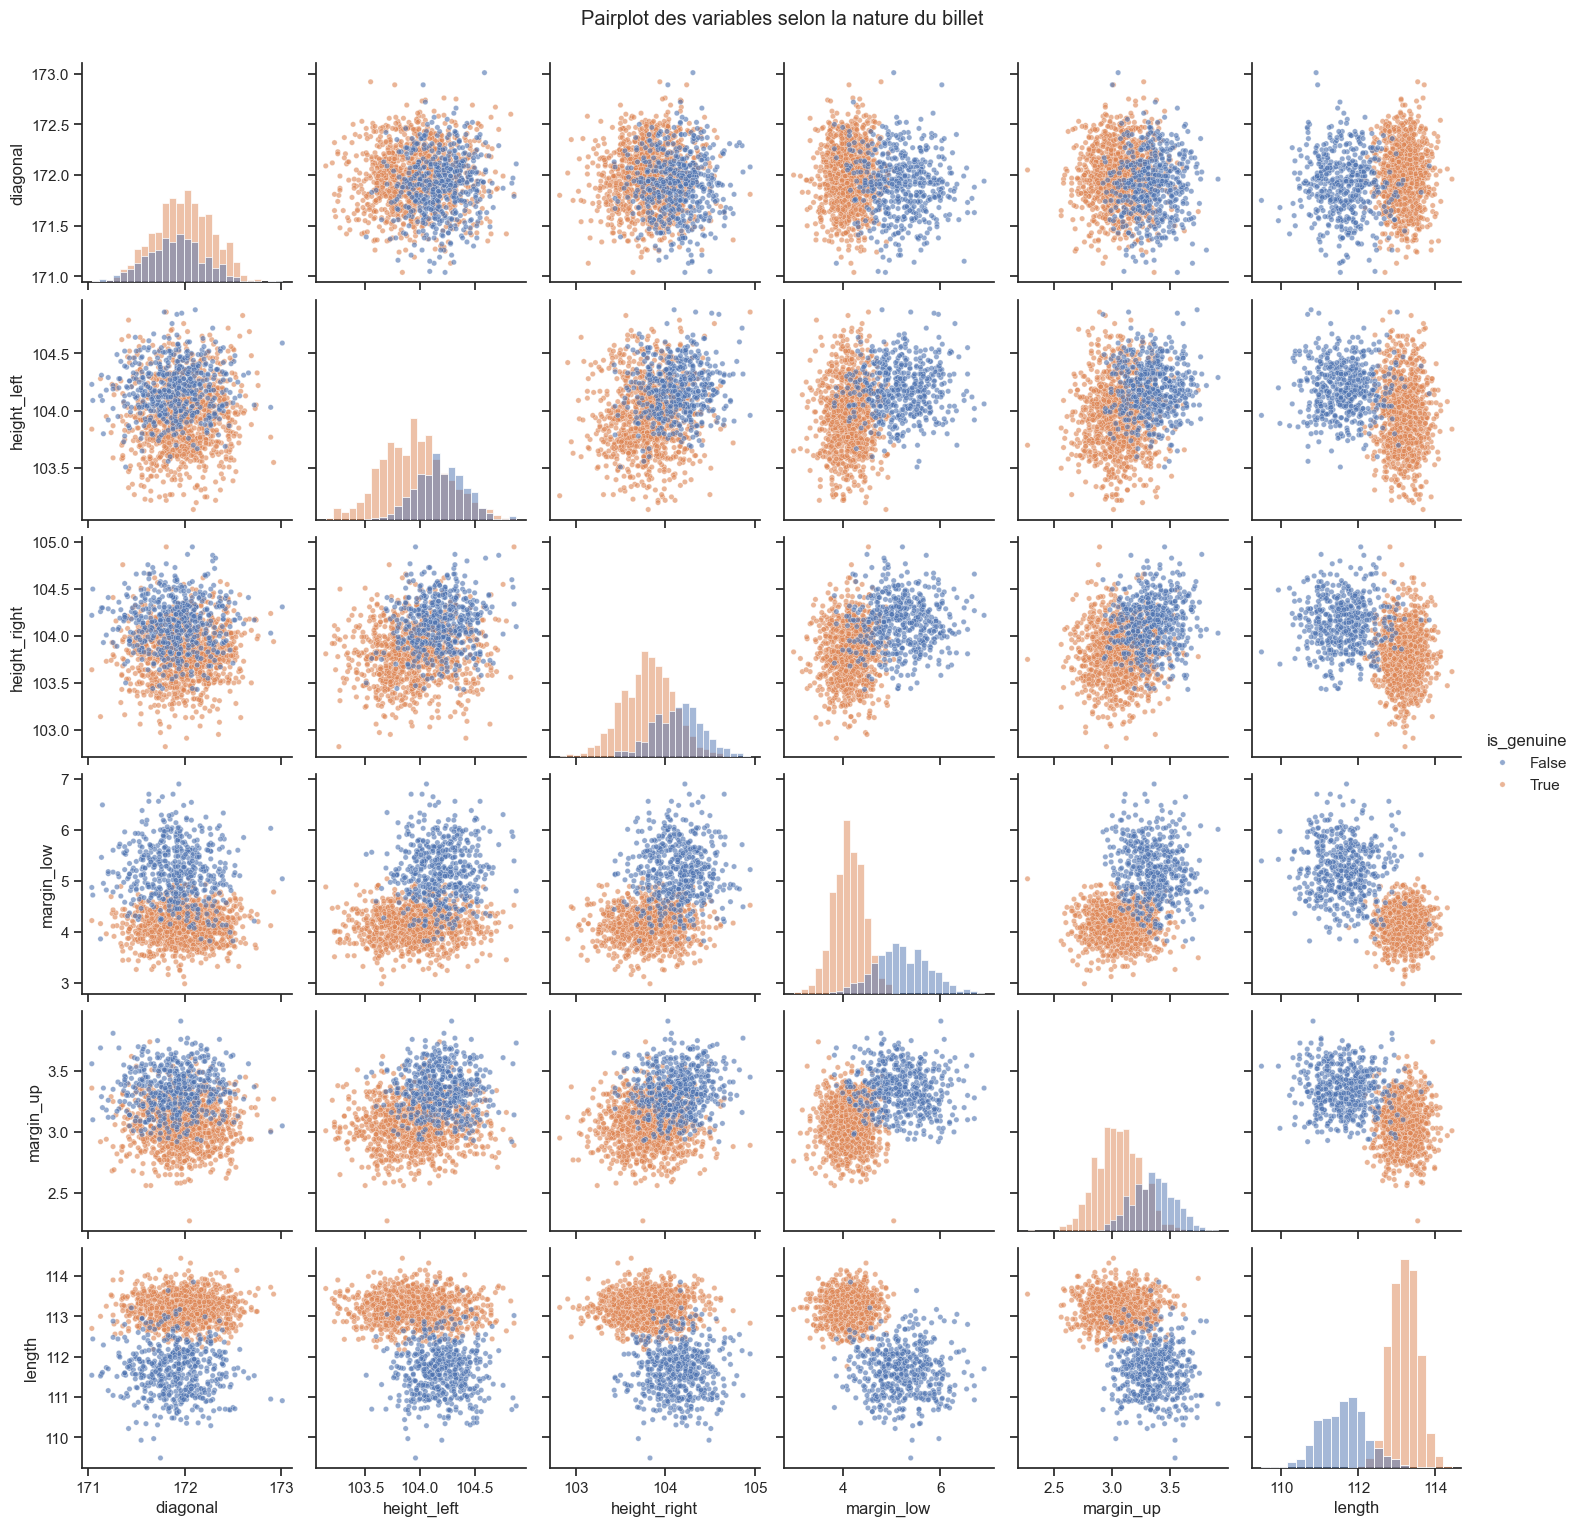

In [76]:

import seaborn as sns
import matplotlib.pyplot as plt

# Pour éviter les problèmes d'affichage avec beaucoup de points
sns.set(style="ticks")

sns.pairplot(
    df,
    hue="is_genuine",
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "s": 15}
)

plt.suptitle("Pairplot des variables selon la nature du billet", y=1.02)
plt.show()

🔎 **Explication technique**

- `sns.set(style="ticks")` : change le style graphique global de seaborn → renvoie `None`.
- `sns.pairplot(...)` : construit une grille de graphiques (histogrammes + nuages de points croisés) → renvoie un objet **`PairGrid`** (pas une simple figure : un objet spécial contenant plusieurs sous-graphiques).
- `hue="is_genuine"` : colore les points selon cette colonne.
- `plt.suptitle(...)` : ajoute un titre général → renvoie un objet `Text`.
- `plt.show()` : affiche la figure → renvoie `None`.

### Interprétation du pairplot

Le pairplot permet d’observer simultanément les distributions de chaque variable ainsi que les relations deux à deux entre les différentes mesures, en distinguant les vrais et les faux billets.


#### Conclusion intermédiaire

Le pairplot montre que :
- les variables sont bien structurées,
- certaines possèdent un pouvoir discriminant naturel,
- les relations entre variables ne sont ni totalement aléatoires ni totalement redondantes.
- L’analyse exploratoire met en évidence que margin_low, margin_up et length sont fortement discriminantes entre billets authentiques et contrefaits. Cette information sera exploitée dans la partie classification, tandis que pour l’imputation de margin_low, l’ensemble des variables explicatives est conservé afin de maximiser la précision de la prédiction.

Cette première exploration visuelle justifie la poursuite de l’analyse via une **matrice de corrélation chiffrée**, afin de quantifier plus précisément ces relations.

### 1. Distribution de la cible

is_genuine
False     500
True     1000
Name: count, dtype: int64
is_genuine
False    33.3
True     66.7
Name: count, dtype: float64


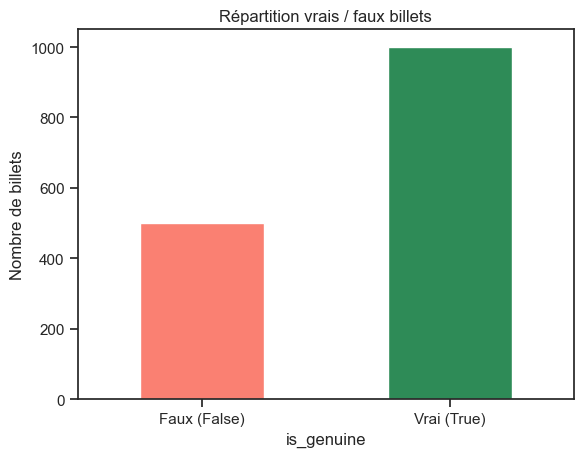

In [77]:
counts = df_trainimpute["is_genuine"].value_counts().sort_index()
print(counts)
print((counts / counts.sum() * 100).round(1))

counts.plot(kind="bar", color=["salmon", "seagreen"])
plt.title("Répartition vrais / faux billets")
plt.xlabel("is_genuine")
plt.ylabel("Nombre de billets")
plt.xticks([0, 1], ["Faux (False)", "Vrai (True)"], rotation=0)
plt.show()

🔎 **Explication technique**

- `df_trainimpute["is_genuine"]` : sélectionne une seule colonne → renvoie une **`Series`**.
- `.value_counts()` : compte les occurrences de chaque valeur unique → renvoie une **`Series`** (index = valeurs, valeurs = comptes), triée par fréquence décroissante par défaut.
- `.sort_index()` : retrie par l'index (ici `False` avant `True`) → renvoie une **nouvelle `Series`**.
- `counts.plot(kind="bar", ...)` : méthode de tracé intégrée à pandas → renvoie un objet **`Axes`** matplotlib.
- `plt.xticks(...)` : fixe positions/labels de l'axe x → renvoie un **tuple** `(positions, labels)`.

### 2. Statistiques descriptives par classe

In [78]:
df_trainimpute.groupby("is_genuine").agg(["mean", "std"]).round(2)

diagonal       height_left       height_right       margin_low  \
               mean   std        mean   std         mean   std       mean   
is_genuine                                                                  
False        171.90  0.31      104.19  0.22       104.14  0.27       5.21   
True         171.99  0.30      103.95  0.30       103.81  0.29       4.12   

                 margin_up        length        
             std      mean   std    mean   std  
is_genuine                                      
False       0.55      3.35  0.18  111.63  0.62  
True        0.32      3.05  0.19  113.20  0.36

🔎 **Explication technique**

- `.groupby("is_genuine")` : ne calcule rien encore, ça prépare un regroupement → renvoie un objet spécial **`DataFrameGroupBy`** (ni DataFrame, ni Series).
- `.agg(["mean", "std"])` : applique les deux calculs à chaque colonne numérique de chaque groupe → renvoie un **`DataFrame`** à colonnes "à deux niveaux" (ex. `diagonal/mean`, `diagonal/std`).
- `.round(2)` : arrondit toutes les valeurs → renvoie un **`DataFrame`**.

### 3. Matrice de corrélation

Corrélation de chaque variable avec is_genuine :
length          0.849
margin_low     -0.783
margin_up      -0.606
height_right   -0.485
height_left    -0.380
diagonal        0.133
Name: is_genuine, dtype: float64


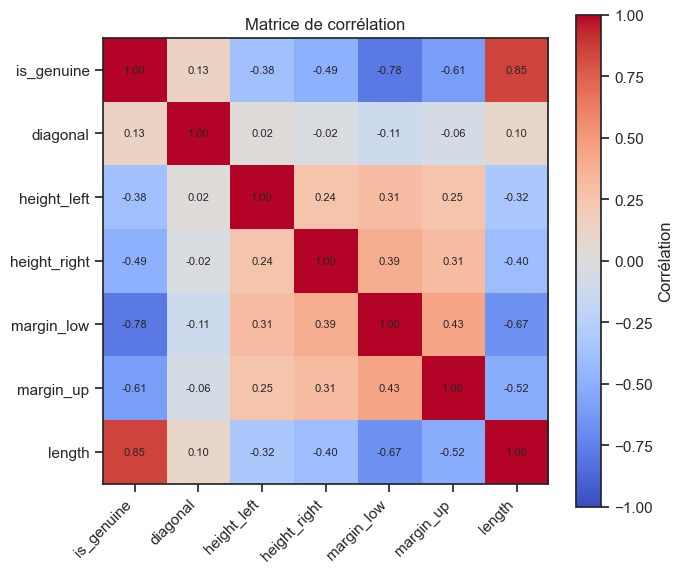

In [79]:
corr = df_trainimpute.corr(numeric_only=True)

corr_avec_cible = corr["is_genuine"].drop("is_genuine").sort_values(key=abs, ascending=False)
print("Corrélation de chaque variable avec is_genuine :")
print(corr_avec_cible.round(3))

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Corrélation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

🔎 **Explication technique**

- `.corr(numeric_only=True)` : calcule les corrélations de Pearson entre chaque paire de colonnes numériques → renvoie un **`DataFrame`** carré (n × n colonnes).
- `corr["is_genuine"]` : sélectionne une colonne de ce DataFrame → renvoie une **`Series`**.
- `.drop("is_genuine")` : sans `inplace=True` → renvoie une **nouvelle `Series`** (l'original n'est pas modifié).
- `.sort_values(key=abs, ascending=False)` : trie par force de corrélation (`key=abs` compare les valeurs absolues pour le tri, mais garde le signe d'origine dans le résultat) → renvoie une **`Series`** triée.
- `plt.imshow(corr, ...)` : affiche un tableau de nombres comme une image colorée → renvoie un objet **`AxesImage`**.
- `plt.colorbar(...)` : ajoute la légende de couleurs → renvoie un objet **`Colorbar`**.
- `plt.text(...)` : ajoute du texte à une position donnée → renvoie un objet **`Text`**.

### Synthèse de l'EDA

Après imputation des valeurs manquantes (régression linéaire sur `margin_low`), le jeu de données conserve l'intégralité de ses 1500 billets : 1000 vrais (66,7%) et 500 faux (33,3%) — un léger déséquilibre qui justifie le `stratify=y` utilisé au moment du split.

**Variables les plus corrélées à `is_genuine`** (par force décroissante) :
1. `length` (≈ 0.85) : les vrais billets sont en moyenne plus longs (≈113.2 mm) que les faux (≈111.6 mm).
2. `margin_low` (≈ -0.78) : les vrais billets ont une marge basse plus petite (≈4.1 mm) que les faux (≈5.2 mm).
3. `margin_up` (≈ -0.61) : même tendance, moins marquée.
4. `height_right` (≈ -0.49) et `height_left` (≈ -0.38) : corrélations modérées.
5. `diagonal` (≈ 0.13) : quasiment aucune corrélation — variable peu discriminante ici.

➡️ Ces résultats confirment l'indice du mentor : `length` et `margin_low` sont les variables les plus informatives pour distinguer un vrai d'un faux billet. On conserve néanmoins toutes les variables pour la modélisation, les modèles utilisés (notamment Random Forest) gérant bien les variables peu informatives.

### 4. Boxplots par classe

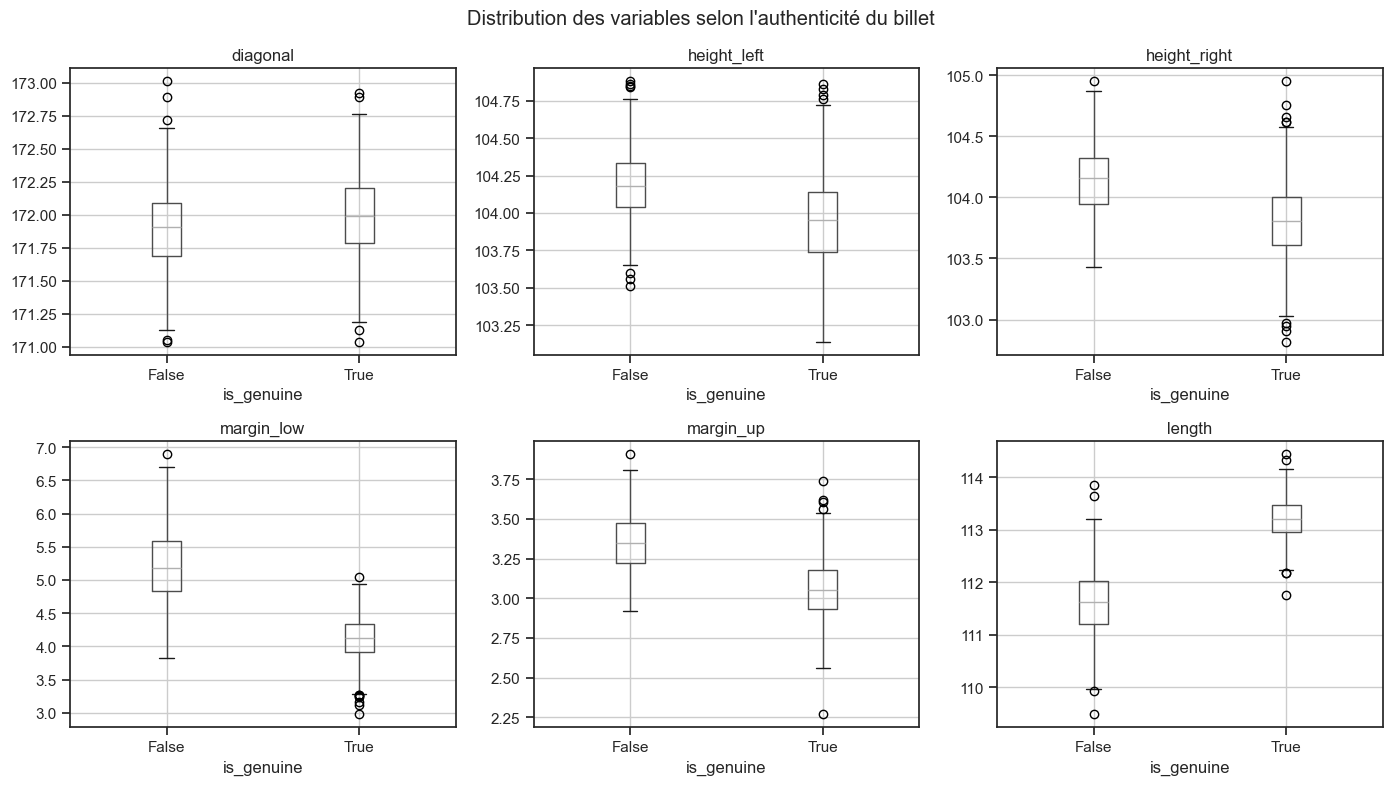

In [80]:
variables = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, var in zip(axes.flatten(), variables):
    df_trainimpute.boxplot(column=var, by="is_genuine", ax=ax)
    ax.set_title(var)
plt.suptitle("Distribution des variables selon l'authenticité du billet")
plt.tight_layout()
plt.show()

🔎 **Explication technique**

- `plt.subplots(2, 3, figsize=(14, 8))` : crée une grille de 2×3 sous-graphiques → renvoie un **tuple** `(Figure, ndarray d'Axes)`, d'où l'écriture `fig, axes = ...`.
- `axes.flatten()` : `axes` est un tableau numpy 2D d'objets Axes ; `.flatten()` l'aplatit en 1D → renvoie un **`ndarray`** à une dimension.
- `zip(axes.flatten(), variables)` : associe chaque Axes à un nom de variable → renvoie un objet **`zip`** (un itérateur).
- `df.boxplot(column=var, by="is_genuine", ax=ax)` : dessine directement sur l'`ax` fourni → renvoie l'**`Axes`** correspondant.
- `ax.set_title(var)` : renvoie un objet `Text`.
- `plt.tight_layout()` : ajuste les espacements → renvoie `None`.

### 5. visualiser la séparation

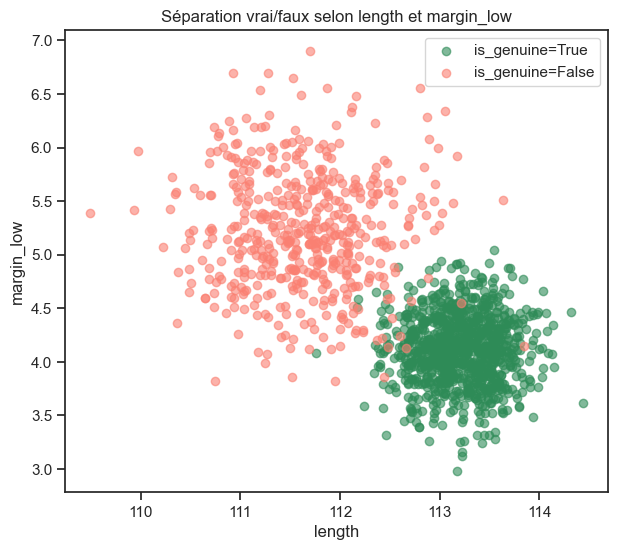

In [81]:
plt.figure(figsize=(7, 6))
for label, color in zip([True, False], ["seagreen", "salmon"]):
    subset = df_trainimpute[df_trainimpute["is_genuine"] == label]
    plt.scatter(subset["length"], subset["margin_low"], label=f"is_genuine={label}", alpha=0.6, color=color)
plt.xlabel("length")
plt.ylabel("margin_low")
plt.title("Séparation vrai/faux selon length et margin_low")
plt.legend()
plt.show()

🔎 **Explication technique**

- `plt.figure(figsize=(7, 6))` : crée une nouvelle figure vide → renvoie un objet **`Figure`**.
- `df_trainimpute["is_genuine"] == label` : compare chaque valeur à `label` → renvoie une **`Series`** de booléens.
- `df_trainimpute[série_de_booléens]` : filtre les lignes où c'est vrai → renvoie un **nouveau `DataFrame`**.
- `plt.scatter(...)` : trace un nuage de points → renvoie un objet **`PathCollection`**.
- `plt.legend()` : affiche la légende → renvoie un objet **`Legend`**.

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [82]:
# La cible : est-ce que le billet est vrai (True) ou faux (False) ?
y = df_trainimpute["is_genuine"]

# Les variables explicatives : toutes les colonnes SAUF la cible
X = df_trainimpute.drop(columns=["is_genuine"])

🔎 **Explication technique**

- `df_trainimpute["is_genuine"]` : renvoie une **`Series`** (la cible `y`).
- `.drop(columns=["is_genuine"])` : sans `inplace=True` → renvoie un **nouveau `DataFrame`** sans cette colonne (`df_trainimpute` original non modifié).

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% des données pour le test, 80% pour l'entraînement
    random_state=42,    # pour que le découpage soit reproductible
    stratify=y          # garde la même proportion vrais/faux dans train et test
)

🔎 **Explication technique**

- `train_test_split(X, y, ...)` : mélange puis découpe les données → renvoie une **liste de 4 éléments**, déballée directement dans 4 variables. Les objets renvoyés gardent le **même type** que ce qu'on lui a donné : `X_train`/`X_test` restent des `DataFrame`, `y_train`/`y_test` restent des `Series`.
- `stratify=y` : garantit que la proportion vrai/faux est respectée dans les deux morceaux.

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Use scaler on X_train and X_test.
X_train_scaled = scaler.fit_transform(X_train)   # apprend la moyenne/écart-type ET transforme
X_test_scaled = scaler.transform(X_test)          # transforme avec les valeurs apprises sur train

🔎 **Explication technique**

- `StandardScaler()` : crée un scaler **non entraîné**.
- `.fit_transform(X_train)` : combine `.fit()` (apprend moyenne/écart-type de chaque colonne) et `.transform()` (applique la standardisation) → ⚠️ renvoie un **`ndarray`** numpy, **pas un DataFrame** : les noms de colonnes sont perdus à partir d'ici.
- `.transform(X_test)` : applique les moyennes/écarts-types **déjà appris sur X_train** → renvoie aussi un **`ndarray`**.
- Pour référence : `.fit()` utilisé seul renvoie l'estimateur **lui-même** (`self`), ce qui permet d'enchaîner `.fit(...).transform(...)`.

# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

In [85]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
log_reg = LogisticRegression(max_iter=1000)  # max_iter augmenté pour laisser au modèle
                                             # le temps de converger (défaut = 100, souvent trop court)

# 2) Entrainez le modèle avec vos données X_train et y_train
log_reg.fit(X_train_scaled, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test
y_pred_log_reg = log_reg.predict(X_test_scaled)



🔎 **Explication technique**

- `LogisticRegression(max_iter=1000)` : crée un modèle **non entraîné**.
- `.fit(X_train_scaled, y_train)` : entraîne le modèle (calcule ses coefficients) → renvoie l'estimateur **lui-même** (`self`), maintenant entraîné. Ici la valeur de retour n'est pas récupérée : seul l'effet de bord (les coefficients stockés dans `log_reg`) nous intéresse.
- `.predict(X_test_scaled)` : utilise les coefficients appris → renvoie un **`ndarray`** 1D des prédictions (`True`/`False`).

### Régression Logistique

**Paramètres ajustables principaux :**
- `max_iter` : nombre maximal d'itérations pour que l'algorithme converge vers une solution. Valeur par défaut = 100, souvent trop faible → on l'augmente (ex. 1000) pour laisser le temps au modèle de trouver ses coefficients optimaux.
- `C` : force de régularisation (inverse). Une petite valeur de `C` pénalise plus fortement les coefficients élevés, ce qui limite le sur-apprentissage.
- `penalty` : type de régularisation appliquée (`l2` par défaut, `l1`, `elasticnet`, ou aucune).
- `solver` : l'algorithme d'optimisation utilisé en interne (`lbfgs` par défaut).

Dans notre cas, on laisse la plupart des paramètres par défaut et on ajuste seulement `max_iter` pour garantir la convergence.

In [86]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)  # n_neighbors = nombre de "voisins" consultés pour voter
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

🔎 **Explication technique**

- `.fit(X_train_scaled, y_train)` : pour le KNN, "entraîner" veut juste dire **stocker** les données (aucun coefficient appris) → renvoie l'estimateur lui-même (`self`).
- `.predict(X_test_scaled)` : regarde les 5 voisins les plus proches et fait voter la majorité → renvoie un **`ndarray`** 1D des prédictions.

### K-Nearest Neighbors (KNN)

**Paramètres ajustables principaux :**
- `n_neighbors` : nombre de voisins consultés pour "voter" la classe d'un point. Trop petit → modèle sensible au bruit (sur-apprentissage). Trop grand → modèle trop lisse qui généralise mal (sous-apprentissage).
- `weights` : comment pondérer les voisins (`uniform` = tous égaux, `distance` = les plus proches comptent plus).
- `metric` : la façon de calculer la distance entre points (par défaut `minkowski`, équivalent à la distance euclidienne).

Contrairement à la régression logistique, le KNN n'apprend pas de coefficients : il stocke simplement les données d'entraînement et compare chaque nouveau point à ses voisins les plus proches. C'est pour cette raison que la standardisation des données (`StandardScaler`) est indispensable : sans elle, une variable avec de grandes valeurs numériques dominerait le calcul de distance.

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 arbres, random_state pour la reproductibilité
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

🔎 **Explication technique**

- `.fit(X_train_scaled, y_train)` : construit 100 arbres de décision sur des sous-échantillons aléatoires → renvoie l'estimateur lui-même (`self`).
- `.predict(X_test_scaled)` : fait voter les 100 arbres et garde la classe majoritaire → renvoie un **`ndarray`** 1D des prédictions.

### Random Forest

**Paramètres ajustables principaux :**
- `n_estimators` : nombre d'arbres de décision construits (plus il y en a, plus le modèle est stable, mais plus long à entraîner).
- `max_depth` : profondeur maximale de chaque arbre (limite le sur-apprentissage si elle est réduite).
- `min_samples_split` / `min_samples_leaf` : nombre minimal d'échantillons requis pour diviser un nœud / former une feuille.
- `random_state` : graine aléatoire pour rendre les résultats reproductibles.

Le Random Forest construit plusieurs arbres de décision sur des sous-échantillons aléatoires des données, puis fait voter l'ensemble pour la prédiction finale. Contrairement au KNN et à la régression logistique, il est **insensible à l'échelle des variables** (pas besoin de standardisation en théorie), mais lui fournir des données standardisées ne pose aucun problème.

In [88]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)  # on demande 2 groupes, en écho aux 2 classes vrai/faux
kmeans.fit(X_train_scaled)          # PAS de y_train ici !
clusters = kmeans.predict(X_test_scaled)

🔎 **Explication technique**

- `KMeans(n_clusters=2, random_state=42)` : crée un modèle de clustering non entraîné.
- `.fit(X_train_scaled)` : **sans `y`** — cherche 2 centres minimisant la distance des points à leur centre le plus proche → renvoie l'estimateur lui-même (`self`).
- `.predict(X_test_scaled)` : attribue chaque point de test au cluster (0 ou 1) le plus proche → renvoie un **`ndarray`** 1D. ⚠️ Ce ne sont pas des `True`/`False`, juste des numéros de groupes arbitraires.

In [89]:
from sklearn.metrics import silhouette_score


print("Inertie :", round(kmeans.inertia_, 2))
silhouette = silhouette_score(X_train_scaled, kmeans.labels_)
print("Silhouette score :", round(silhouette, 3))


comparaison = pd.crosstab(clusters, y_test.values, rownames=["cluster"], colnames=["is_genuine (réel)"])
print(comparaison)

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_df["cluster"] = clusters
print(X_test_df.groupby("cluster").mean().round(2))

Inertie : 4642.93
Silhouette score : 0.345
is_genuine (réel)  False  True 
cluster                        
0                     98      2
1                      2    198
         diagonal  height_left  height_right  margin_low  margin_up  length
cluster                                                                    
0           -0.20         0.58          0.75        1.14       0.86   -1.12
1            0.07        -0.34         -0.34       -0.64      -0.44    0.65


🔎 **Explication technique**

- `kmeans.inertia_` : ⚠️ pas une méthode (pas de parenthèses), c'est un **attribut** rempli après le `.fit()` → un simple **`float`** (somme des distances au carré entre chaque point et son centre).
- `kmeans.labels_` : autre attribut rempli après le `.fit()` → un **`ndarray`** donnant le cluster de **chaque point d'entraînement** (à ne pas confondre avec `clusters`, qui vient du `.predict()` sur le jeu de test).
- `silhouette_score(...)` : renvoie un simple **`float`** entre -1 et 1.
- `pd.crosstab(...)` : construit un tableau croisé de comptages → renvoie un **`DataFrame`**.
- `pd.DataFrame(X_test_scaled, columns=X.columns)` : reconstruit un DataFrame à partir d'un `ndarray`, en redonnant les noms de colonnes perdus depuis le `StandardScaler` → renvoie un **`DataFrame`**.
- `X_test_df["cluster"] = clusters` : pas un appel de fonction mais une **affectation** — ajoute une colonne directement en mémoire, sans rien "renvoyer".
- `.groupby("cluster").mean()` : renvoie un **`DataFrame`** (moyenne de chaque variable, par cluster).

### Évaluation et caractérisation des clusters

**Forme des clusters (point 9) :** le silhouette score obtenu est d'environ 0.35 — une séparation modérée mais réelle (proche de 0 = clusters qui se chevauchent, proche de 1 = clusters parfaitement distincts).

**Caractérisation des groupes (points 7 et 10) :** en comparant les clusters aux vraies étiquettes :
- Cluster 0 : 98 faux billets pour seulement 2 vrais (≈98% de faux) → correspond aux **faux billets**.
- Cluster 1 : 198 vrais billets pour 2 seuls faux (≈99% de vrais) → correspond aux **vrais billets**.

Le profil moyen confirme cette lecture : le cluster "faux" a une `margin_low` bien plus élevée (+1.14 écart-type) et une `length` bien plus faible (-1.12) que le cluster "vrai" — exactement les variables identifiées comme discriminantes dans l'EDA.

**Justification de la méthode (point 8) :** même sans utiliser `is_genuine`, KMeans retrouve presque parfaitement les deux classes réelles, ce qui confirme que la frontière entre vrais et faux billets est bien marquée dans les données géométriques. Cela dit, puisqu'on dispose déjà des vraies étiquettes, un modèle supervisé (Régression Logistique) reste l'outil le plus fiable pour un usage en production — KMeans sert ici de vérification exploratoire, pas d'outil de prédiction final.

### Qu'est-ce que le silhouette score ?

Pour chaque billet, on compare sa distance moyenne aux autres billets de son propre cluster (a) à sa distance moyenne aux billets de l'autre cluster (b). Le score obtenu, (b-a)/max(a,b), vaut entre -1 et 1 : proche de 1 signifie un point bien à sa place, proche de 0 un point à la frontière entre les deux clusters, négatif un point probablement mal classé. Le silhouette score global est la moyenne de ce score sur tous les billets.

On considère généralement qu'un score entre 0,26 et 0,50 indique une structure faible à modérée : les deux clusters existent bien, sans être aussi nettement séparés qu'avec un score au-delà de 0,7. Le score obtenu ici (0,345) est cohérent avec les 4 erreurs observées dans le tableau croisé (des billets à la frontière entre les deux groupes).

### KMeans

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Le cahier des charges demande d'utiliser les centroïdes de KMeans pour prédire :
# on mappe chaque cluster à sa classe majoritaire (déterminée sur les données d'entraînement)
mapping = {}
for c in [0, 1]:
    mask = kmeans.labels_ == c
    mapping[c] = y_train[mask].mode()[0]
print("Correspondance cluster → classe :", mapping)

# Prédiction sur le jeu de test, via le centroïde le plus proche
y_pred_kmeans = pd.Series(clusters).map(mapping).values

print("\n=== KMeans comme modèle de prédiction (via centroïdes) ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_kmeans), 3))
print("Precision:", round(precision_score(y_test, y_pred_kmeans), 3))
print("Recall   :", round(recall_score(y_test, y_pred_kmeans), 3))
print("F1-score :", round(f1_score(y_test, y_pred_kmeans), 3))
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred_kmeans))

Correspondance cluster → classe : {0: np.False_, 1: np.True_}

=== KMeans comme modèle de prédiction (via centroïdes) ===
Accuracy : 0.987
Precision: 0.99
Recall   : 0.99
F1-score : 0.99
Matrice de confusion :
 [[ 98   2]
 [  2 198]]


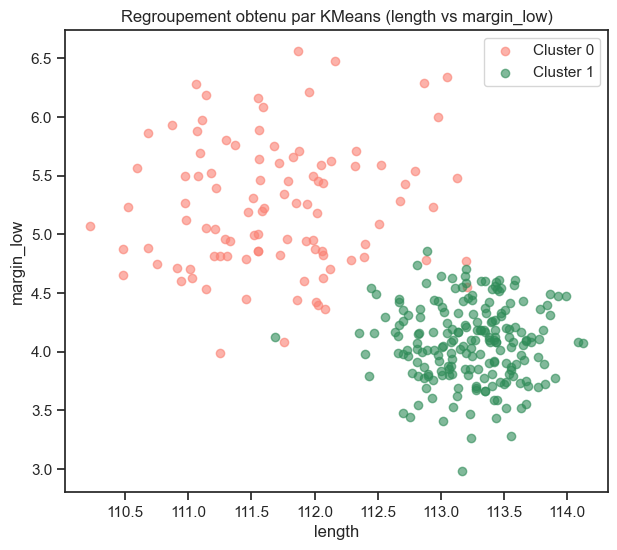

In [91]:
plt.figure(figsize=(7, 6))
for cluster_id, color in zip([0, 1], ["salmon", "seagreen"]):
    subset = X_test[clusters == cluster_id]
    plt.scatter(subset["length"], subset["margin_low"], label=f"Cluster {cluster_id}", alpha=0.6, color=color)
plt.xlabel("length")
plt.ylabel("margin_low")
plt.title("Regroupement obtenu par KMeans (length vs margin_low)")
plt.legend()
plt.show()



**Différence fondamentale avec les 3 modèles précédents :**
KMeans est un algorithme de **clustering non supervisé**, alors que la régression logistique, le KNN et le Random Forest sont des algorithmes de **classification supervisée**.

Concrètement :
- Les 3 modèles précédents utilisent `y_train` (l'étiquette vrai/faux) pendant l'entraînement (`.fit(X_train, y_train)`) pour apprendre à prédire cette étiquette.
- KMeans, lui, ne reçoit **jamais** `y` : il ne fait que regrouper les points de `X` en `n_clusters` groupes, selon leur proximité, sans aucune notion de "vrai" ou "faux" billet.
- Les groupes (clusters) obtenus sont numérotés arbitrairement (0, 1, ...) : rien ne garantit que le cluster 0 corresponde aux vrais billets et le cluster 1 aux faux (ou l'inverse) — il faut vérifier après coup en comparant aux vraies étiquettes.

**Est-ce pertinent pour cette étude ?**
Pas vraiment comme outil principal : nous disposons déjà des vraies étiquettes (`is_genuine`), donc il s'agit d'un problème de classification supervisée, pas de clustering. KMeans peut éventuellement servir à des fins exploratoires (vérifier si les billets se séparent naturellement en 2 groupes cohérents sans utiliser l'étiquette), mais ce n'est pas l'algorithme adapté pour prédire l'authenticité d'un billet.

### KMeans comme méthode de prédiction

Le cahier des charges demande explicitement de mettre en concurrence 4 méthodes de prédiction, K-means y compris, en utilisant ses centroïdes pour prédire :
1. On regarde, pour chaque cluster (déterminé sur les données d'entraînement), la classe majoritaire des billets qui s'y trouvent — ceci définit une correspondance cluster → classe.
2. Pour prédire un nouveau billet, on l'assigne au centroïde le plus proche (`kmeans.predict()`), puis on lui attribue la classe majoritaire de ce cluster.

| Modèle | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|
| KMeans (via centroïdes) | 0,987 | 0,99 | 0,99 | 0,99 |
| Régression Logistique | 0,99 | 0,99 | 0,995 | 0,993 |
| KNN | 0,983 | 0,985 | 0,99 | 0,988 |
| Random Forest | 0,99 | 0,99 | 0,995 | 0,993 |

Même utilisé comme un vrai prédicteur, K-means obtient un excellent score (98,7% d'accuracy, 2 faux positifs et 2 faux négatifs sur 300 billets) — supérieur à KNN, et à seulement 0,3 point de la Régression Logistique et du Random Forest. La Régression Logistique reste néanmoins retenue comme modèle final : légèrement meilleure sur toutes les métriques, et bien plus simple à interpréter et déployer qu'un pipeline de clustering nécessitant une étape supplémentaire de correspondance cluster → classe.

In [92]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

def evaluer_modele(nom, y_true, y_pred, y_proba=None):
    print(f"=== {nom} ===")
    print("Accuracy  :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision :", round(precision_score(y_true, y_pred), 3))
    print("Recall    :", round(recall_score(y_true, y_pred), 3))
    print("F1-score  :", round(f1_score(y_true, y_pred), 3))
    if y_proba is not None:
        print("ROC AUC   :", round(roc_auc_score(y_true, y_proba), 3))
    print()
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Faux", "Vrai"])
    disp.plot(cmap="Blues")
    plt.title(f"Matrice de confusion - {nom}")
    plt.show()

🔎 **Explication technique**

- `def evaluer_modele(...):` ne renvoie rien au moment où on l'écrit : ça crée un **objet fonction**, utilisable plus tard. Cette fonction n'a pas de `return` explicite → quand on l'appelle, elle renvoie automatiquement `None` (son rôle est d'afficher des résultats, pas d'en renvoyer).
- `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score` : chacune renvoie un simple **`float`** entre 0 et 1.
- `classification_report(...)` : renvoie une **chaîne de caractères (`str`)** déjà mise en forme, prête pour `print()`.
- `confusion_matrix(...)` : renvoie un **`ndarray`** 2D (ici 2×2).
- `ConfusionMatrixDisplay(confusion_matrix=cm, ...)` : crée un objet d'affichage, sans encore rien dessiner.
- `.plot(cmap="Blues")` : dessine réellement la matrice → renvoie l'objet `ConfusionMatrixDisplay` **lui-même**, maintenant avec le graphique attaché.

=== Régression Logistique ===
Accuracy  : 0.99
Precision : 0.99
Recall    : 0.995
F1-score  : 0.993
ROC AUC   : 1.0

              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



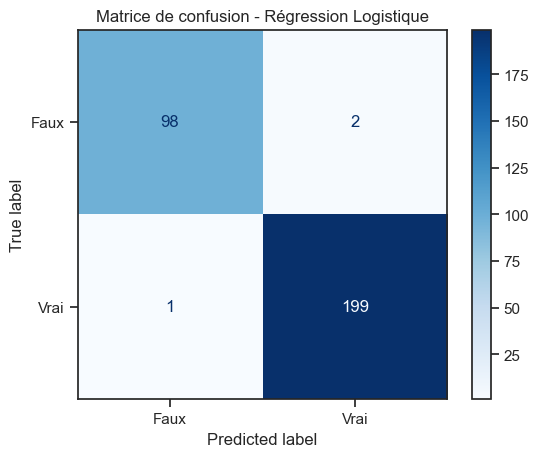

=== KNN ===
Accuracy  : 0.983
Precision : 0.985
Recall    : 0.99
F1-score  : 0.988
ROC AUC   : 0.997

              precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



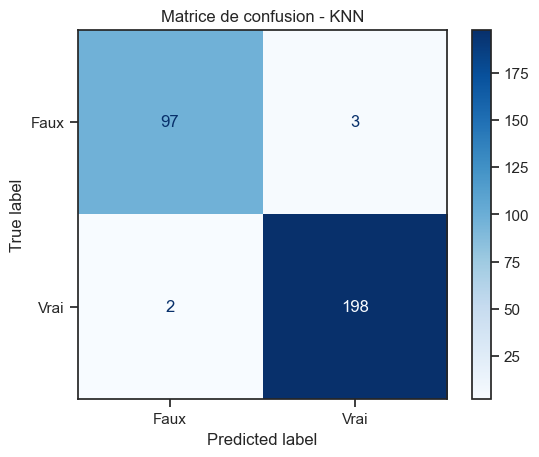

=== Random Forest ===
Accuracy  : 0.99
Precision : 0.99
Recall    : 0.995
F1-score  : 0.993
ROC AUC   : 0.999

              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



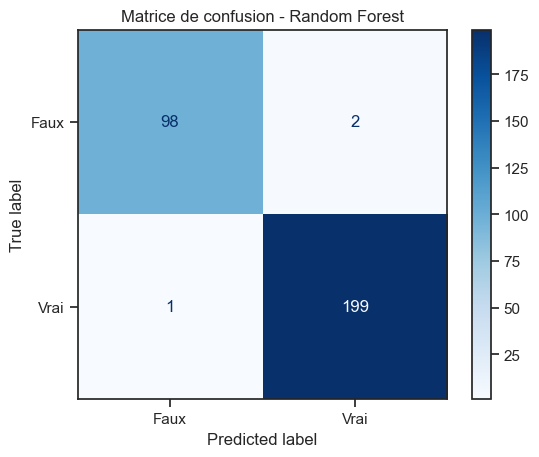

In [93]:
# Régression logistique
y_proba_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluer_modele("Régression Logistique", y_test, y_pred_log_reg, y_proba_log_reg)

# KNN
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]
evaluer_modele("KNN", y_test, y_pred_knn, y_proba_knn)

# Random Forest
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
evaluer_modele("Random Forest", y_test, y_pred_rf, y_proba_rf)

### Comprendre les métriques d'évaluation

Pour un billet donné, 4 cas sont possibles : Vrai Positif (VP, vrai billet bien détecté), Faux Positif (FP, un faux billet validé à tort comme vrai — l'erreur la plus grave dans notre contexte), Vrai Négatif (VN, faux billet bien détecté) et Faux Négatif (FN, vrai billet rejeté à tort).

- **Accuracy** = (VP+VN) / total : proportion globale de bonnes prédictions.
- **Precision** = VP / (VP+FP) : quand le modèle prédit "vrai", à quel point peut-on lui faire confiance.
- **Recall** = VP / (VP+FN) : parmi les vrais billets, la proportion effectivement détectée.
- **F1-score** : moyenne harmonique de la precision et du recall, un compromis global entre les deux.
- **ROC AUC** : mesure la capacité du modèle à bien séparer les deux classes, indépendamment du seuil de décision (0,5 par défaut) — 0,5 = aléatoire, 1,0 = séparation parfaite.

Le `classification_report` et la matrice de confusion affichés ci-dessous permettent de retrouver directement VP, FP, VN et FN pour chaque modèle.

🔎 **Explication technique**

- `.predict_proba(X_test_scaled)` : renvoie un **`ndarray`** 2D de forme (nombre de billets, 2) : une colonne = probabilité "Faux", l'autre = probabilité "Vrai".
- `[:, 1]` : notation numpy — "toutes les lignes, seulement la colonne d'index 1" (probabilité du `True`, les classes étant ordonnées `False` puis `True`) → renvoie un **`ndarray`** 1D.
- `evaluer_modele(...)` : appelle notre fonction définie plus haut ; comme elle n'a pas de `return`, l'appel renvoie `None` — mais affiche bien les métriques et le graphique en effet de bord.

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

### Sélection du meilleur modèle

| Modèle | Accuracy | Precision | Recall | F1-score | ROC AUC |
|---|---|---|---|---|---|
| Régression Logistique | 0.99 | 0.99 | 0.995 | 0.993 | 1.0 |
| KNN | 0.983 | 0.985 | 0.99 | 0.988 | 0.997 |
| Random Forest | 0.99 | 0.99 | 0.995 | 0.993 | 0.999 |

Les trois modèles obtiennent d'excellents résultats, ce qui s'explique par la forte corrélation entre `length`/`margin_low` et `is_genuine` observée dans l'EDA.

- **Régression Logistique** et **Random Forest** sont quasiment à égalité : sur les 300 billets du jeu de test, seulement 2 faux billets sont classés à tort comme vrais (faux positifs) et 1 vrai billet à tort comme faux (faux négatif), pour les deux modèles.
- **KNN** est légèrement en retrait : 3 faux positifs et 2 faux négatifs, avec un ROC AUC de 0,997 contre 1,0 et 0,999 pour les deux autres.

L'erreur la plus grave ici, d'un point de vue métier, est le **faux positif** (valider un faux billet comme vrai) : Régression Logistique et Random Forest restent les meilleurs sur ce point.

**Modèle retenu : Régression Logistique.** À performance quasi identique avec Random Forest, on choisit le modèle le plus simple et le plus interprétable plutôt que d'ajouter la complexité d'une forêt de 100 arbres sans gain de score.

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [94]:
from sklearn.pipeline import make_pipeline
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# On combine le StandardScaler et le modèle retenu (Régression Logistique) en un seul objet
pipeline_final = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# On entraîne le pipeline sur les données BRUTES (non standardisées) :
# le pipeline applique lui-même le scaler avant d'appeler le modèle
pipeline_final.fit(X_train, y_train)

# Vérification : on doit retrouver la même accuracy que log_reg évalué plus haut
print("Accuracy du pipeline sur X_test :", round(pipeline_final.score(X_test, y_test), 3))

# Sauvegarde du pipeline complet (scaler + modèle) dans un seul fichier
joblib.dump(pipeline_final, "modele_detection_faux_billets.joblib")
print("✅ Modèle sauvegardé sous 'modele_detection_faux_billets.joblib'")

Accuracy du pipeline sur X_test : 0.99
✅ Modèle sauvegardé sous 'modele_detection_faux_billets.joblib'


🔎 **Explication technique**

- `make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))` : chaîne plusieurs étapes en un seul objet → renvoie un objet **`Pipeline`**.
- `pipeline_final.fit(X_train, y_train)` : entraîne **toutes les étapes d'un coup** (le scaler apprend et transforme, puis le modèle s'entraîne sur le résultat) → renvoie le pipeline lui-même (`self`), maintenant entièrement entraîné.
- `pipeline_final.score(X_test, y_test)` : méthode pratique disponible sur tout modèle/pipeline entraîné ; fait `.predict()` puis compare aux vraies valeurs → renvoie un simple **`float`** (l'accuracy, par défaut pour un classifieur).
- `joblib.dump(pipeline_final, "...")` : sauvegarde l'objet Python sur le disque → renvoie une **liste** contenant le(s) nom(s) de fichier(s) écrit(s).